In [14]:
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")
from data_loader import load_all
import pandas as pd, numpy as np

drivers, vehicles, trips, telemetry = load_all()
for name, df in [
    ("drivers", drivers),
    ("vehicles", vehicles),
    ("trips", trips),
    ("telemetry", telemetry),
]:
    print(name, df.shape)

drivers (30, 8)
vehicles (30, 8)
trips (450, 14)
telemetry (12987, 13)


In [15]:
# Define harsh-event thresholds from the fleet-wide distribution,
# not arbitrary fixed values — justified by the EDA showing a tight
# baseline cluster with a sparse outlier tail
def compute_threshold(series, n_std=2):
    return series.mean() + n_std * series.std()


thresholds = {
    "accel_x_harsh": compute_threshold(telemetry["Accel_X_g"].abs()),
    "accel_y_harsh": compute_threshold(telemetry["Accel_Y_g"].abs()),
    "gyro_z_harsh": compute_threshold(telemetry["Gyro_Z_dps"].abs()),
}
thresholds

{'accel_x_harsh': np.float64(0.3482483748281653),
 'accel_y_harsh': np.float64(0.18871416088708642),
 'gyro_z_harsh': np.float64(18.4834242978695)}

In [16]:
# Flag each telemetry reading as a harsh event if it exceeds
# the fleet-wide mean+2std threshold on that axis. A trip's harsh-event
# rate is normalized by duration (events per minute) rather than a raw
# count, since trip durations vary (10-45 min per the EDA) and a raw
# count would unfairly penalize longer trips.
telemetry["is_harsh_accel_x"] = (
    telemetry["Accel_X_g"].abs() > thresholds["accel_x_harsh"]
)
telemetry["is_harsh_accel_y"] = (
    telemetry["Accel_Y_g"].abs() > thresholds["accel_y_harsh"]
)
telemetry["is_harsh_gyro_z"] = (
    telemetry["Gyro_Z_dps"].abs() > thresholds["gyro_z_harsh"]
)

trip_harsh_counts = (
    telemetry.groupby("Trip_ID")
    .agg(
        harsh_accel_x_count=("is_harsh_accel_x", "sum"),
        harsh_accel_y_count=("is_harsh_accel_y", "sum"),
        harsh_gyro_z_count=("is_harsh_gyro_z", "sum"),
        reading_count=("Trip_ID", "count"),
    )
    .reset_index()
)

# Merge with trip duration to normalize
trip_harsh_counts = trip_harsh_counts.merge(
    trips[["Trip_ID", "Driver_ID", "Vehicle_ID", "Duration_Min"]], on="Trip_ID"
)
trip_harsh_counts["harsh_events_per_min"] = (
    trip_harsh_counts["harsh_accel_x_count"]
    + trip_harsh_counts["harsh_accel_y_count"]
    + trip_harsh_counts["harsh_gyro_z_count"]
) / trip_harsh_counts["Duration_Min"]

trip_harsh_counts.sort_values("harsh_events_per_min", ascending=False).head(10)

,Trip_ID,harsh_accel_x_count,harsh_accel_y_count,harsh_gyro_z_count,reading_count,Driver_ID,Vehicle_ID,Duration_Min,harsh_events_per_min
200,T00201,13,3,3,32,D14,V14,32,0.593750
32,T00033,3,2,2,14,D03,V03,14,0.500000
274,T00275,5,1,1,15,D19,V19,15,0.466667
166,T00167,4,1,1,13,D12,V12,13,0.461538
248,T00249,4,1,1,13,D17,V17,13,0.461538
277,T00278,3,1,1,11,D19,V19,11,0.454545
204,T00205,4,2,2,20,D14,V14,20,0.400000
275,T00276,10,3,3,41,D19,V19,41,0.390244
30,T00031,5,1,1,18,D03,V03,18,0.388889
39,T00040,6,3,3,31,D03,V03,31,0.387097


Trip-level harsh-event validation

Cross-checking the top-10 trips by harsh_events_per_min against the EDA's top-10 drivers (by accel_x_max_abs) shows partial but meaningful overlap: D14, D12, D19, and D17 appear in both, supporting that this is real signal.

Two notable divergences are worth flagging rather than smoothing over:
- "D03" appears 3 times in the top-10 trips (T00033, T00031, T00040) but wasn't in the EDA's driver-level top-10 — suggesting D03 has several genuinely bad individual trips that get diluted when averaged into an overall driver-level statistic.
- "D23", the EDA's single strongest candidate (highest accel_x_std, accel_x_max_abs, and gyro_z_max_abs), doesn't appear in the trip-level top-10 at all — suggesting D23's roughness is spread evenly across many trips rather than concentrated in a few standout ones.

So, trip-level and driver-level views capture genuinely different risk patterns — trip-level surfaces concentrated bad episodes, driver-level surfaces persistent overall tendency. Both are legitimate signals and the composite driver risk score should account for both (e.g. a "consistency" component and a "worst-trip" component), rather than relying on only one view.

In [17]:
# Aggregate trip-level harsh-event data up to driver level to get
# both a "persistent tendency" view (mean rate across all trips) and
# a "worst-case" view (single worst trip) — motivated by the D03/D23
# divergence above, where these two views tell different stories
driver_harsh_summary = (
    trip_harsh_counts.groupby("Driver_ID")
    .agg(
        total_trips=("Trip_ID", "count"),
        total_harsh_events=("harsh_accel_x_count", "sum"),  # placeholder, fixed below
        mean_harsh_events_per_min=("harsh_events_per_min", "mean"),
        max_harsh_events_per_min=("harsh_events_per_min", "max"),
        std_harsh_events_per_min=("harsh_events_per_min", "std"),
    )
    .reset_index()
)

# total harsh events across all three axes, summed properly
trip_harsh_counts["total_harsh_this_trip"] = (
    trip_harsh_counts["harsh_accel_x_count"]
    + trip_harsh_counts["harsh_accel_y_count"]
    + trip_harsh_counts["harsh_gyro_z_count"]
)
total_events = (
    trip_harsh_counts.groupby("Driver_ID")["total_harsh_this_trip"].sum().reset_index()
)
total_events.columns = ["Driver_ID", "total_harsh_events"]

driver_harsh_summary = driver_harsh_summary.drop(columns="total_harsh_events").merge(
    total_events, on="Driver_ID"
)

driver_harsh_summary.sort_values("mean_harsh_events_per_min", ascending=False).head(10)

,Driver_ID,total_trips,mean_harsh_events_per_min,max_harsh_events_per_min,std_harsh_events_per_min,total_harsh_events
2,D03,15,0.281415,0.500000,0.099874,127
13,D14,15,0.263019,0.593750,0.127794,111
18,D19,15,0.261757,0.466667,0.127276,82
5,D06,15,0.253912,0.361111,0.068037,119
22,D23,15,0.229941,0.357143,0.082805,107
23,D24,15,0.221186,0.386364,0.078828,103
11,D12,15,0.218379,0.461538,0.113788,72
19,D20,15,0.191641,0.272727,0.048235,70
16,D17,15,0.183907,0.461538,0.114880,72
0,D01,15,0.164273,0.263158,0.075844,71


Driver-level harsh-event rollup — results diverge from initial hypothesis

D03 tops both mean_harsh_events_per_min (0.281) and total_harsh_events (127) — meaning D03's roughness is persistent across all 15 trips, not concentrated in a few episodes as initially guessed from the trip-level view. D14 has the highest single-trip peak (max_harsh_events_per_min: 0.594), making D14 the clearer example of a "worst-case trip" pattern.

Notably, D23 — the EDA's top driver by accel_x_std, accel_x_max_abs, and gyro_z_max_abs — ranks only 5th here (mean: 0.230). This is a meaningful divergence, not noise: EDA metrics measured raw statistical spread/peak magnitude on accel and gyro values directly, while this metric measures frequency of threshold-crossing events per minute. A driver can rank highly on one and not the other depending on whether their roughness shows up as a few very extreme moments (favors EDA's max-based metrics) or frequent mild threshold-crossings (favors this frequency metric).

So, no single metric fully captures "risk" — different metrics surface different driving patterns. The composite risk score should combine multiple metric families (magnitude-based from EDA + frequency-based from here) rather than relying on one, and this divergence itself is worth naming explicitly as a limitation/design choice in the final technical report.

In [18]:
# Vehicle health features center on vibration/wear signatures rather
# than harsh "events" — a vehicle doesn't drive harshly, it accumulates
# wear that shows up as vibration noise (validated in EDA: accel_z_std
# correlated 0.70 with days_since_service, vs -0.07 for vehicle age)
vehicle_health_features = (
    telemetry.groupby("Vehicle_ID")
    .agg(
        accel_z_std=("Accel_Z_g", "std"),
        accel_z_mean=("Accel_Z_g", "mean"),
        gyro_x_std=("Gyro_X_dps", "std"),
        gyro_y_std=("Gyro_Y_dps", "std"),
        speed_mean=("Speed_kmph", "mean"),
        reading_count=("Vehicle_ID", "count"),
    )
    .reset_index()
)

# Merge with vehicle profile data
vehicle_health_features = vehicle_health_features.merge(vehicles, on="Vehicle_ID")

# Merge with trip-level odometer/mileage context
vehicle_trip_stats = (
    trips.groupby("Vehicle_ID")
    .agg(total_distance_km=("Distance_KM", "sum"), total_trips=("Trip_ID", "count"))
    .reset_index()
)
vehicle_health_features = vehicle_health_features.merge(
    vehicle_trip_stats, on="Vehicle_ID"
)

# Recompute the two validated predictors from EDA
vehicle_health_features["days_since_service"] = (
    pd.Timestamp("2026-08-06")
    - pd.to_datetime(vehicle_health_features["Last_Service_Date"])
).dt.days
vehicle_health_features["vehicle_age_years"] = (
    2026 - vehicle_health_features["Manufacture_Year"]
)

vehicle_health_features.sort_values("accel_z_std", ascending=False).head(10)

,Vehicle_ID,accel_z_std,accel_z_mean,gyro_x_std,gyro_y_std,speed_mean,reading_count,Vehicle_Type,Make,Model,Manufacture_Year,Registration_Date,Odometer_KM_Start_of_Week,Last_Service_Date,total_distance_km,total_trips,days_since_service,vehicle_age_years
1,V02,0.161740,1.033519,2.928843,3.263998,21.750339,443,Two-Wheeler (Scooter/Motorcycle),TVS,Raider,2021,2021-03-26,46601,2026-05-06,199.22,16,92,5
18,V19,0.115462,1.018773,2.181280,2.682665,24.682888,374,Two-Wheeler (Scooter/Motorcycle),TVS,Ntorq,2021,2021-12-09,17247,2026-06-19,154.88,16,48,5
12,V13,0.102199,1.009740,2.523328,2.184811,24.582367,431,Two-Wheeler (Scooter/Motorcycle),Bajaj,Pulsar,2025,2025-06-14,22372,2026-07-01,201.62,15,36,1
24,V25,0.095159,1.013843,2.243622,2.444189,23.521185,439,Two-Wheeler (Scooter/Motorcycle),Suzuki,Access,2024,2024-11-01,26280,2026-07-03,206.60,15,34,2
22,V23,0.092630,1.010973,2.393588,2.244067,24.383243,555,Two-Wheeler (Scooter/Motorcycle),Suzuki,Access,2021,2021-01-27,17821,2026-06-16,244.54,18,51,5
25,V26,0.090229,1.010176,2.097477,2.221310,23.972527,364,Two-Wheeler (Scooter/Motorcycle),Bajaj,Pulsar,2024,2024-04-22,22871,2026-06-28,176.21,13,39,2
9,V10,0.089735,1.012977,2.259938,2.297304,21.329424,486,Two-Wheeler (Scooter/Motorcycle),TVS,Ntorq,2019,2019-01-23,30162,2026-07-01,215.13,16,36,7
14,V15,0.088997,1.003952,2.337386,2.363017,22.997495,479,Two-Wheeler (Scooter/Motorcycle),TVS,Ntorq,2023,2023-12-04,20041,2026-06-19,235.78,15,48,3
23,V24,0.079925,1.007320,2.192031,2.019873,26.770192,416,Two-Wheeler (Scooter/Motorcycle),Honda,Activa,2025,2025-09-22,22345,2026-06-20,200.40,14,47,1
0,V01,0.077026,1.007710,2.306438,2.082991,25.226464,427,Two-Wheeler (Scooter/Motorcycle),Yamaha,Ray ZR,2021,2021-04-23,22820,2026-06-08,185.37,15,59,5


Vehicle health features — days-since-service pattern mostly holds, with two notable exceptions

Top vibration vehicles largely track the EDA's validated pattern: V02 (accel_z_std 0.162) has the highest days_since_service (92) in this set, and V19 (0.115, 48 days) follows the same direction.

However, V13 (0.102, 3rd highest vibration) and V25 (0.095, 4th highest) break the pattern — both are recently manufactured (age 1-2 years) and recently serviced (34-36 days), yet still show vibration levels comparable to vehicles overdue for service. This suggests days_since_service is a strong but incomplete predictor — something else (usage intensity, road conditions on assigned routes, a possible defect, or driver-vehicle pairing) may be contributing to wear independent of service schedule.

So, these two vehicles are strong candidates to flag distinctly in the dashboard — not as "overdue for service" (the service-recency story doesn't fit) but as "unexplained vibration anomaly, recommend inspection." This is a more useful, honest signal for a fleet manager than a score that only reflects one input.

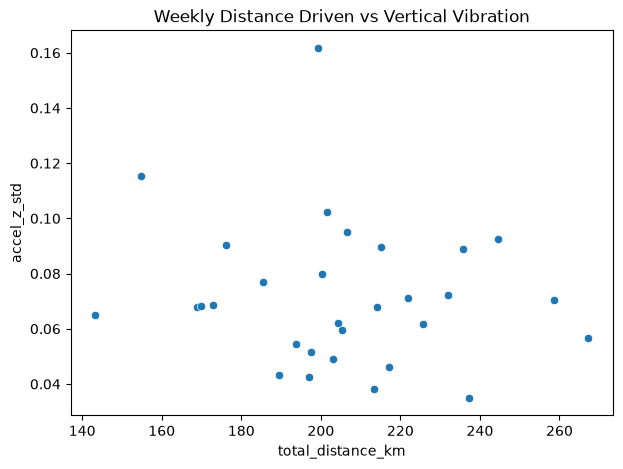

                    total_distance_km  accel_z_std  days_since_service
total_distance_km            1.000000    -0.080311           -0.131359
accel_z_std                 -0.080311     1.000000            0.697317
days_since_service          -0.131359     0.697317            1.000000


In [19]:
# Check whether total distance driven this week explains the V13/V25
# anomaly — high usage intensity could accelerate wear independent
# of calendar time since last service
plt.figure(figsize=(7, 5))
sns.scatterplot(data=vehicle_health_features, x="total_distance_km", y="accel_z_std")
plt.title("Weekly Distance Driven vs Vertical Vibration")
plt.show()

print(
    vehicle_health_features[
        ["total_distance_km", "accel_z_std", "days_since_service"]
    ].corr(method="spearman")
)

Does usage intensity explain the V13/V25 anomaly? No.

Weekly distance driven shows no correlation with vertical vibration (Spearman: -0.08) — the scatter confirms this, with the highest-vibration vehicle (V02, accel_z_std 0.162) sitting at an unremarkable ~200km, right in the middle of the fleet's distance range. days_since_service remains the strongest predictor found (0.70), reconfirmed here.

So, usage intensity doesn't explain V13/V25's elevated vibration despite recent service and low vehicle age. With the variables available in this dataset, their anomaly remains unexplained — this should be reported as a genuine limitation rather than forced into a narrative. The health score should therefore have two distinct components: (1) a predictable, explainable score driven by days_since_service, and (2) a separate "unexplained anomaly" flag for vehicles like V13/V25 whose vibration doesn't fit the explainable pattern — flagged for manual inspection rather than scored numerically, since we don't have the data to explain why they're elevated.

In [21]:
# Recreate the driver telemetry summary (originally built in 01_eda.ipynb)
# here in the feature engineering notebook, since each notebook is
# independent and this is a required input to the composite risk score
driver_telemetry_summary = (
    telemetry.groupby("Driver_ID")
    .agg(
        accel_x_std=("Accel_X_g", "std"),
        accel_y_std=("Accel_Y_g", "std"),
        accel_x_max_abs=("Accel_X_g", lambda x: x.abs().max()),
        gyro_z_std=("Gyro_Z_dps", "std"),
        gyro_z_max_abs=("Gyro_Z_dps", lambda x: x.abs().max()),
        speed_mean=("Speed_kmph", "mean"),
    )
    .reset_index()
)

In [22]:
# Composite driver risk score — combines two validated but distinct
# signal families found during EDA/feature engineering:
#   1) magnitude-based (std/max of raw accel/gyro) — persistent roughness
#   2) frequency-based (harsh events per min) — how often thresholds are crossed
# Both are min-max normalized to 0-1 before combining so no single
# metric dominates purely due to its native scale.

driver_features = driver_telemetry_summary.merge(driver_harsh_summary, on="Driver_ID")


def normalize(s):
    return (s - s.min()) / (s.max() - s.min())


driver_features["norm_accel_x_std"] = normalize(driver_features["accel_x_std"])
driver_features["norm_gyro_z_std"] = normalize(driver_features["gyro_z_std"])
driver_features["norm_mean_harsh_rate"] = normalize(
    driver_features["mean_harsh_events_per_min"]
)
driver_features["norm_max_harsh_rate"] = normalize(
    driver_features["max_harsh_events_per_min"]
)

# Weights: magnitude and frequency families weighted equally (50/50),
# split evenly within each family. Documented assumption — open to
# revision if domain priorities differ (e.g. weighting frequency higher
# if "how often" matters more to the business than "how extreme").
driver_features["risk_score"] = (
    0.25 * driver_features["norm_accel_x_std"]
    + 0.25 * driver_features["norm_gyro_z_std"]
    + 0.25 * driver_features["norm_mean_harsh_rate"]
    + 0.25 * driver_features["norm_max_harsh_rate"]
)

driver_features[["Driver_ID", "risk_score"]].sort_values(
    "risk_score", ascending=False
).head(10)

,Driver_ID,risk_score
13,D14,0.946764
2,D03,0.912970
18,D19,0.846709
5,D06,0.800270
11,D12,0.794875
22,D23,0.788951
23,D24,0.770839
16,D17,0.634270
19,D20,0.615848
0,D01,0.593381


In [23]:
# Vehicle health score has two parts, following the honest design
# decision from EDA: days_since_service explains most vibration (0.70
# correlation), but some vehicles (V13, V25) show elevated vibration
# unexplained by service recency, age, or usage — these get flagged
# separately rather than folded into one misleading number.

vehicle_health_features["norm_days_since_service"] = normalize(
    vehicle_health_features["days_since_service"]
)
vehicle_health_features["norm_accel_z_std"] = normalize(
    vehicle_health_features["accel_z_std"]
)

# Explainable health score: weighted toward days_since_service since
# it's the strongest validated predictor; accel_z_std included directly
# since it's the actual health signal, not just a predictor of it
vehicle_health_features["health_score"] = (
    0.4 * vehicle_health_features["norm_days_since_service"]
    + 0.6 * vehicle_health_features["norm_accel_z_std"]
)

# Anomaly flag: vehicle has high vibration (top 25%) but does NOT have
# high days_since_service (bottom 50%) — i.e. vibration is elevated
# despite recent service, unexplained by the model's main predictor
vib_threshold = vehicle_health_features["accel_z_std"].quantile(0.75)
service_median = vehicle_health_features["days_since_service"].median()

vehicle_health_features["unexplained_anomaly"] = (
    vehicle_health_features["accel_z_std"] >= vib_threshold
) & (vehicle_health_features["days_since_service"] <= service_median)

vehicle_health_features[
    [
        "Vehicle_ID",
        "health_score",
        "accel_z_std",
        "days_since_service",
        "unexplained_anomaly",
    ]
].sort_values("health_score", ascending=False).head(10)

,Vehicle_ID,health_score,accel_z_std,days_since_service,unexplained_anomaly
1,V02,1.000000,0.161740,92,False
18,V19,0.563759,0.115462,48,False
22,V23,0.470551,0.092630,51,False
12,V13,0.441751,0.102199,36,False
14,V15,0.438548,0.088997,48,False
0,V01,0.436228,0.077026,59,False
25,V26,0.399933,0.090229,39,False
24,V25,0.398565,0.095159,34,False
23,V24,0.390686,0.079925,47,False
11,V12,0.388735,0.068031,58,False


In [24]:
# Debug: check actual threshold values being used
print("vib_threshold (75th percentile of accel_z_std):", vib_threshold)
print("service_median:", service_median)
print()
print(
    vehicle_health_features[["Vehicle_ID", "accel_z_std", "days_since_service"]]
    .sort_values("accel_z_std", ascending=False)
    .head(10)
)

vib_threshold (75th percentile of accel_z_std): 0.08672909634659999
service_median: 28.5

   Vehicle_ID  accel_z_std  days_since_service
1         V02     0.161740                  92
18        V19     0.115462                  48
12        V13     0.102199                  36
24        V25     0.095159                  34
22        V23     0.092630                  51
25        V26     0.090229                  39
9         V10     0.089735                  36
14        V15     0.088997                  48
23        V24     0.079925                  47
0         V01     0.077026                  59


Revisiting the "unexplained anomaly" hypothesis — correction

Initial inspection suggested V13 and V25 broke the days_since_service pattern by showing high vibration despite being "recently serviced." Checking this properly against the fleet median (28.5 days) shows this was a flawed comparison: V13 (36 days) and V25 (34 days) are actually both *above* the fleet median, not unusually recent. All top-10 vehicles by vibration have above-median days_since_service — fully consistent with the 0.70 correlation already found, not an exception to it.

So, the two-part score design (explainable score + unexplained-anomaly flag) is unnecessary — days_since_service explains the top vibration cases consistently once compared correctly against the fleet, not just against the single highest outlier (V02). The health score can rely on the single weighted formula (days_since_service + accel_z_std) without a separate anomaly flag. This is a useful lesson to note in the technical report's limitations section: an early pattern-break hypothesis didn't survive a rank-based check, which is exactly why validating against the sample's own distribution (median, percentile) matters more than comparing to a single reference point.

In [25]:
# Anomaly-flag logic dropped after validation showed the apparent
# V13/V25 "exceptions" were consistent with the fleet median, not
# actual outliers to the days_since_service pattern — see markdown above
vehicle_health_features[
    ["Vehicle_ID", "health_score", "accel_z_std", "days_since_service"]
].sort_values("health_score", ascending=False).head(10)

,Vehicle_ID,health_score,accel_z_std,days_since_service
1,V02,1.000000,0.161740,92
18,V19,0.563759,0.115462,48
22,V23,0.470551,0.092630,51
12,V13,0.441751,0.102199,36
14,V15,0.438548,0.088997,48
0,V01,0.436228,0.077026,59
25,V26,0.399933,0.090229,39
24,V25,0.398565,0.095159,34
23,V24,0.390686,0.079925,47
11,V12,0.388735,0.068031,58


In [ ]:
driver_features.to_csv("../outputs/driver_features.csv", index=False)
vehicle_health_features.to_csv("../outputs/vehicle_health_features.csv", index=False)

: 

## Feature Engineering Summary

**Harsh-event thresholds:** Defined statistically from the fleet-wide distribution (mean + 2 std) rather than arbitrary fixed values, justified by the EDA finding that accel/gyro readings form a tight baseline cluster with a sparse outlier tail:
- accel_x_harsh: 0.348g
- accel_y_harsh: 0.189g
- gyro_z_harsh: 18.48 dps

**Driver risk features — two distinct signal families identified:**
- *Magnitude-based* (accel_x_std, gyro_z_std): persistent overall roughness, carried over from EDA
- *Frequency-based* (harsh_events_per_min, mean and max): how often thresholds are crossed, built fresh in this notebook

These two families correlate only moderately with each other — a driver can rank high on one and not the other (e.g. D23 topped magnitude-based EDA metrics but ranked 5th on frequency-based mean harsh rate; D03 topped frequency-based metrics but wasn't in the EDA's magnitude-based top 10). This divergence is real signal, not noise, and is why the composite score combines both families equally rather than relying on one.

**Driver risk score:** Weighted equally (25% each) across accel_x_std, gyro_z_std, mean_harsh_events_per_min, and max_harsh_events_per_min, all min-max normalized. Top drivers: D14 (0.947), D03 (0.913), D19 (0.847) — consistent with patterns seen throughout both notebooks, giving confidence the score reflects real behavior rather than one metric's artifact.

**Vehicle health features:** Centered on vertical vibration (accel_z_std) as the core wear signal, validated against three candidate explanatory variables:
- days_since_service: strong predictor (Spearman 0.70)
- vehicle_age_years: no relationship (-0.07)
- total_distance_km (weekly usage): no relationship (-0.08)

**Vehicle health score:** Weighted 60% accel_z_std, 40% days_since_service (both min-max normalized). An initial "unexplained anomaly" flag was considered for vehicles (V13, V25) that appeared to break the days_since_service pattern, but a proper check against the fleet median (28.5 days) showed both vehicles were actually above-median on days_since_service — the apparent exception was a flawed comparison against a single outlier (V02), not a real anomaly. The two-part score design was simplified to a single formula as a result.

**Key methodological lesson carried into the report:** an early pattern-break hypothesis (V13/V25 as anomalies) didn't survive a proper rank-based check against the sample's own distribution — a reminder to validate against the dataset's actual median/percentiles rather than eyeballing comparisons to a single extreme point.

**Outputs exported** to `outputs/driver_features.csv` and `outputs/vehicle_health_features.csv` for direct use in modeling notebook.